# Imports

In [1]:
import seaborn as sns
import numpy as np 
import pandas as pd
import datatable as dt

import matplotlib.pyplot as plt
%matplotlib inline

pd.set_option('display.max_columns', None)

# Load dataset

In [2]:
%%time
train = dt.fread('../input/tabular-playground-series-nov-2021/train.csv').to_pandas()
test  = dt.fread('../input/tabular-playground-series-nov-2021/test.csv').to_pandas()
sub   = dt.fread('../input/tabular-playground-series-nov-2021/sample_submission.csv').to_pandas()

CPU times: user 6.49 s, sys: 1.83 s, total: 8.32 s
Wall time: 6.41 s


# General overview

In [3]:
train.head(5)

,id,f0,f1,f2,f3,f4,f5,f6,f7,f8,f9,f10,f11,f12,f13,f14,f15,f16,f17,f18,f19,f20,f21,f22,f23,f24,f25,f26,f27,f28,f29,f30,f31,f32,f33,f34,f35,f36,f37,f38,f39,f40,f41,f42,f43,f44,f45,f46,f47,f48,f49,f50,f51,f52,f53,f54,f55,f56,f57,f58,f59,f60,f61,f62,f63,f64,f65,f66,f67,f68,f69,f70,f71,f72,f73,f74,f75,f76,f77,f78,f79,f80,f81,f82,f83,f84,f85,f86,f87,f88,f89,f90,f91,f92,f93,f94,f95,f96,f97,f98,f99,target
0,0,0.106643,3.59437,132.8040,3.18428,0.081971,1.18859,3.73238,2.266270,2.09959,0.012330,1.607190,-0.318058,0.560137,2.806880,1.35114,2.535930,0.197527,0.676494,1.98979,-3.842450,0.037380,0.230322,3.33055,0.009397,0.144738,3.05131,1.30362,0.033225,-0.018284,2.748210,-0.009294,-0.036271,-0.049871,0.019484,3.898460,11.2863,1.138020,3.366880,4.94446,-0.105772,2.11345,3.452230,0.789430,1.113210,1.49157,2.440370,0.041824,3.35537,0.053691,1.701270,0.908831,0.094902,0.030219,0.597024,4.443410,1.586490,-0.068686,-0.108268,0.061044,0.046099,0.017113,-0.027551,0.019483,-0.048826,0.050748,3.729300,5.017440,4.186880,0.063342,0.121043,1.37175,4.017450,0.167613,0.039753,2.042360,-0.016614,0.107679,3.507250,0.013660,-0.097023,5.396070,0.244457,3.49184,0.113090,-0.015472,4.208790,4.106560,0.037227,-0.118814,0.067086,0.010739,1.09862,0.013331,-0.011715,0.052759,0.065400,4.211250,1.97877,0.085974,0.240496,False
1,1,0.125021,1.67336,76.5336,3.37825,0.099400,5.09366,1.27562,-0.471318,4.54594,0.037706,0.331749,0.325091,0.062040,2.262150,4.33943,-0.224999,0.233586,3.381280,1.90299,0.067874,-0.051268,0.006135,2.60444,0.103441,0.067638,4.75362,1.85552,-0.181834,0.008359,3.166340,0.011850,0.022292,0.069320,0.117109,0.315276,24.4807,1.672270,-0.409067,4.95475,0.092358,2.60318,1.954690,0.005896,3.289340,2.56453,0.817706,0.025997,4.61749,1.575540,0.066105,0.681634,0.025247,0.183500,0.110038,2.746120,0.835586,0.188196,4.960640,0.136087,-0.008493,-0.015264,-0.010841,0.064584,0.102548,0.093611,0.964089,0.630422,4.307340,0.091289,-0.036360,3.61767,3.103240,0.000657,0.051302,1.924620,0.123294,-0.022671,1.548120,-0.010397,0.058330,3.661310,-0.118386,2.35739,-0.009112,0.178701,4.097350,3.532890,0.005244,0.121381,0.109968,0.135838,3.46017,0.017054,0.124863,0.154064,0.606848,-0.267928,2.57786,-0.020877,0.024719,False
2,2,0.036330,1.49747,233.5460,2.19435,0.026914,3.12694,5.05687,3.849460,1.80187,0.056995,0.328684,2.968810,0.105244,2.069490,5.30986,1.354790,-0.262018,1.379080,1.48091,0.020542,-0.008806,0.109348,1.68365,0.038180,0.123716,1.11248,3.57166,0.120601,0.082069,2.233520,0.002270,0.045182,0.014405,0.011599,-0.502849,33.7382,1.417500,1.071350,3.22296,2.122030,3.08216,0.637555,-0.006822,-0.390943,17.34570,3.700430,-0.033600,1.57824,0.051978,-0.002004,2.690960,0.018367,-0.030468,0.111409,2.187470,-0.325000,-0.019944,3.455030,0.068105,-0.009812,-0.010627,0.027571,-0.007121,-0.048914,-0.002574,1.865090,2.404170,0.411741,0.057749,0.525174,2.16879,0.828297,0.089848,0.093744,4.949010,-0.010978,0.076671,0.266784,0.038691,0.382731,3.847600,-0.121482,3.74084,0.147098,-0.016566,0.614651,2.125840,0.078828,0.979808,0.026758,0.117310,4.88300,0.085222,0.032396,0.116092,-0.001688,-0.520069,2.14112,0.124464,0.148209,False
3,3,-0.014077,0.24600,779.9670,1.89064,0.006948,1.53112,2.69800,4.517330,4.50332,0.123494,1.002680,4.869600,0.058411,2.497850,1.23843,2.348360,0.175475,1.608890,2.02881,0.042086,0.005141,0.076506,1.65122,0.111813,0.121641,0.58912,4.23692,-0.032843,0.058168,0.712927,0.097465,0.072744,0.000324,0.063362,4.063820,25.3824,0.576572,2.026210,2.96843,1.085670,1.71088,1.371820,0.034631,0.722607,71.44850,3.034580,0.092245,3.45310,0.044829,0.027195,4.082850,0.046955,0.063695,0.029225,0.672022,0.185311,0.164284,3.804560,0.062306,-0.021406,0.009471,0.110884,0.026837,2.931160,0.068112,-0.495192,1.345280,2.242750,0.035611,-0.139274,4.74243,3.292740,0.117877,0.065605,0.556711,-0.058029,0.070501,1.101250,0.068559,0.162928,4.070180,-0.008835,3.89678,0.913739,-0.163204,3.074850,4.356780,-0.048894,4.917990,0.069930,-0.015347,3.47439,-0.017103,-0.008100,0.062013,0.041193,0.511657,1.9

In [4]:
train.info(verbose=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 600000 entries, 0 to 599999
Data columns (total 102 columns):
 #    Column  Dtype  
---   ------  -----  
 0    id      int32  
 1    f0      float64
 2    f1      float64
 3    f2      float64
 4    f3      float64
 5    f4      float64
 6    f5      float64
 7    f6      float64
 8    f7      float64
 9    f8      float64
 10   f9      float64
 11   f10     float64
 12   f11     float64
 13   f12     float64
 14   f13     float64
 15   f14     float64
 16   f15     float64
 17   f16     float64
 18   f17     float64
 19   f18     float64
 20   f19     float64
 21   f20     float64
 22   f21     float64
 23   f22     float64
 24   f23     float64
 25   f24     float64
 26   f25     float64
 27   f26     float64
 28   f27     float64
 29   f28     float64
 30   f29     float64
 31   f30     float64
 32   f31     float64
 33   f32     float64
 34   f33     float64
 35   f34     float64
 36   f35     float64
 37   f36     float64
 38   f3

In [5]:
train.describe()

,id,f0,f1,f2,f3,f4,f5,f6,f7,f8,f9,f10,f11,f12,f13,f14,f15,f16,f17,f18,f19,f20,f21,f22,f23,f24,f25,f26,f27,f28,f29,f30,f31,f32,f33,f34,f35,f36,f37,f38,f39,f40,f41,f42,f43,f44,f45,f46,f47,f48,f49,f50,f51,f52,f53,f54,f55,f56,f57,f58,f59,f60,f61,f62,f63,f64,f65,f66,f67,f68,f69,f70,f71,f72,f73,f74,f75,f76,f77,f78,f79,f80,f81,f82,f83,f84,f85,f86,f87,f88,f89,f90,f91,f92,f93,f94,f95,f96,f97,f98,f99
count,600000.000000,600000.000000,600000.000000,600000.000000,600000.000000,600000.000000,600000.000000,600000.000000,600000.000000,600000.000000,600000.000000,600000.000000,600000.000000,600000.000000,600000.000000,600000.000000,600000.000000,600000.000000,600000.000000,600000.000000,600000.000000,600000.000000,600000.000000,600000.000000,600000.000000,600000.000000,600000.000000,600000.000000,600000.000000,600000.000000,600000.000000,600000.000000,600000.000000,600000.000000,600000.000000,600000.000000,600000.000000,600000.000000,600000.000000,600000.000000,600000.000000,600000.000000,600000.000000,600000.000000,600000.000000,600000.000000,600000.000000,600000.000000,600000.000000,600000.000000,600000.000000,600000.000000,600000.000000,600000.000000,600000.000000,600000.000000,600000.000000,600000.000000,600000.000000,600000.000000,600000.000000,600000.000000,600000.000000,600000.000000,600000.000000,600000.000000,600000.000000,600000.000000,600000.000000,600000.000000,600000.000000,600000.000000,600000.000000,600000.000000,600000.000000,600000.000000,600000.000000,600000.000000,600000.000000,600000.000000,600000.000000,600000.000000,600000.000000,600000.000000,600000.000000,600000.000000,600000.000000,600000.000000,600000.000000,600000.000000,600000.000000,600000.000000,600000.000000,600000.000000,600000.000000,600000.000000,600000.000000,600000.000000,600000.000000,600000.000000,600000.000000
mean,299999.500000,0.306508,2.497590,306.644536,2.647901,0.177850,2.556832,2.699650,2.571593,2.538273,0.134370,2.579987,2.759273,0.128958,2.477244,2.662859,2.631040,0.362479,2.483075,2.471319,0.108097,0.093783,0.062157,2.559781,0.097061,0.141055,2.580093,2.459101,0.057945,0.216789,2.471344,0.125638,0.107798,0.170434,0.054776,2.463409,55.698848,1.769510,2.595079,2.410926,0.593497,2.646091,2.582621,0.108999,2.500058,3.227368,2.595892,0.061749,2.537154,0.084997,0.244993,2.558957,0.093148,0.314877,0.109274,2.455216,2.571747,0.270019,2.604276,0.099612,0.087340,0.088858,0.144262,0.124303,0.340198,0.086385,2.513444,2.577005,2.522315,0.134467,0.189364,2.494925,2.632673,0.129834,0.050814,2.551266,0.174057,0.231822,2.420256,0.101771,0.349875,2.550175,0.902983,2.598029,0.162773,0.501982,2.587270,2.653461,0.265197,0.335756,0.056866,0.071252,2.444471,0.155260,0.059407,0.144932,0.106419,2.547853,2.590159,0.158881,0.123048
std,173205.225094,0.522450,1.554018,551.743893,1.544529,0.417488,1.562527,1.564000,1.549361,1.532988,0.421892,1.604389,1.545217,0.210861,1.517694,1.481966,1.531067,1.346352,1.577456,1.541571,0.395313,0.308938,0.054796,1.556496,0.333590,0.342377,1.609573,1.567891,0.114129,0.339320,1.524330,0.296563,0.412291,0.440615,0.109661,1.566572,130.132892,1.785712,1.562506,1.572078,0.951892,1.567926,1.537063,0.356046,1.575150,5.414258,1.559765,0.365426,1.502016,0.292977,0.622615,1.611025,0.341598,0.579662,0.201639,1.533550,1.485223,0.852348,1.532116,0.590106,0.432437,0.151993,0.377962,0.414040,0.623011,0.216007,1.516342,1.563820,1.532317,0.398998,0.744550,1.575232,1.541872,0.308313,0.049142,1.513612,0.641809,1.206276,1.557891,0.245734,0.596830,1.576794,1.335611,1.542775,0.295831,2.364291,1.564173,1.546943,0.562230,0.993598,0.128607,0.112654,1.542509,0.548397,0.119426,0.462015,0.209128,1.558427,1.525091,0.436190,0.264896
min,0.000000,-3.797450,-1.223960,-1842.530000,-1.368560,-3.206210,-1.169770,-1.059310,-1.281970,-1.242020,-2.577840,-1.309730,-1.451570,-0.678145,-1.295160,-1.213890,-1.450540,-18.169600,-1.387720,-1.221020,-5.334110,-2.858550,-0.151519,-1.201070,-2.721660,-2.645250,-1.380430,-1.147260,-2.281050,-4.596700,-1.225650,-2.025710,-3.273000,-1.95

In [6]:
def nan_counts(df):
    null_counts = df.isna().sum()
    info_df = pd.DataFrame(list(zip(null_counts.index,null_counts.values))\
                                         , columns = ['Column', 'nan_counts'])
    data_types = df.dtypes
    info_df['Dtype'] = data_types.values
    return info_df.T

In [7]:
nan_counts(train)

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53,54,55,56,57,58,59,60,61,62,63,64,65,66,67,68,69,70,71,72,73,74,75,76,77,78,79,80,81,82,83,84,85,86,87,88,89,90,91,92,93,94,95,96,97,98,99,100,101
Column,id,f0,f1,f2,f3,f4,f5,f6,f7,f8,f9,f10,f11,f12,f13,f14,f15,f16,f17,f18,f19,f20,f21,f22,f23,f24,f25,f26,f27,f28,f29,f30,f31,f32,f33,f34,f35,f36,f37,f38,f39,f40,f41,f42,f43,f44,f45,f46,f47,f48,f49,f50,f51,f52,f53,f54,f55,f56,f57,f58,f59,f60,f61,f62,f63,f64,f65,f66,f67,f68,f69,f70,f71,f72,f73,f74,f75,f76,f77,f78,f79,f80,f81,f82,f83,f84,f85,f86,f87,f88,f89,f90,f91,f92,f93,f94,f95,f96,f97,f98,f99,target
nan_counts,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
Dtype,int32,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,bool


# Feature distribution

In [8]:
def plot_feature_distribution(train, test):
    fig = plt.figure(figsize = (15, 71))
    cols = train.columns.tolist()[1:119]
    for i in cols:
        plt.subplot(24,5,cols.index(i)+1)
        sns.set_style("white")
        plt.title(i, size = 12, fontname = 'monospace')
        a = sns.kdeplot(train[i], color = '#f9ba32', linewidth = 1.3)
        sns.kdeplot(test[i], color = '#426e86', linewidth = 1.3)
        plt.ylabel('')
        plt.xlabel('')
        plt.xticks(fontname = 'monospace')
        plt.yticks([])
        for j in ['right', 'left', 'top']:
            a.spines[j].set_visible(False)
            a.spines['bottom'].set_linewidth(1.2)

    fig.tight_layout(h_pad = 3)

    plt.figtext(0.335, 1.02, 'Distribution of features', color = '#2f3131', fontname = 'monospace', size = 25)
    plt.figtext(0.3, 1.01, 'train', color = '#f9ba32', fontname = 'monospace', size = 18)
    plt.figtext(0.66, 1.01, 'test', color = '#426e86', fontname = 'monospace', size = 18)

    plt.show()

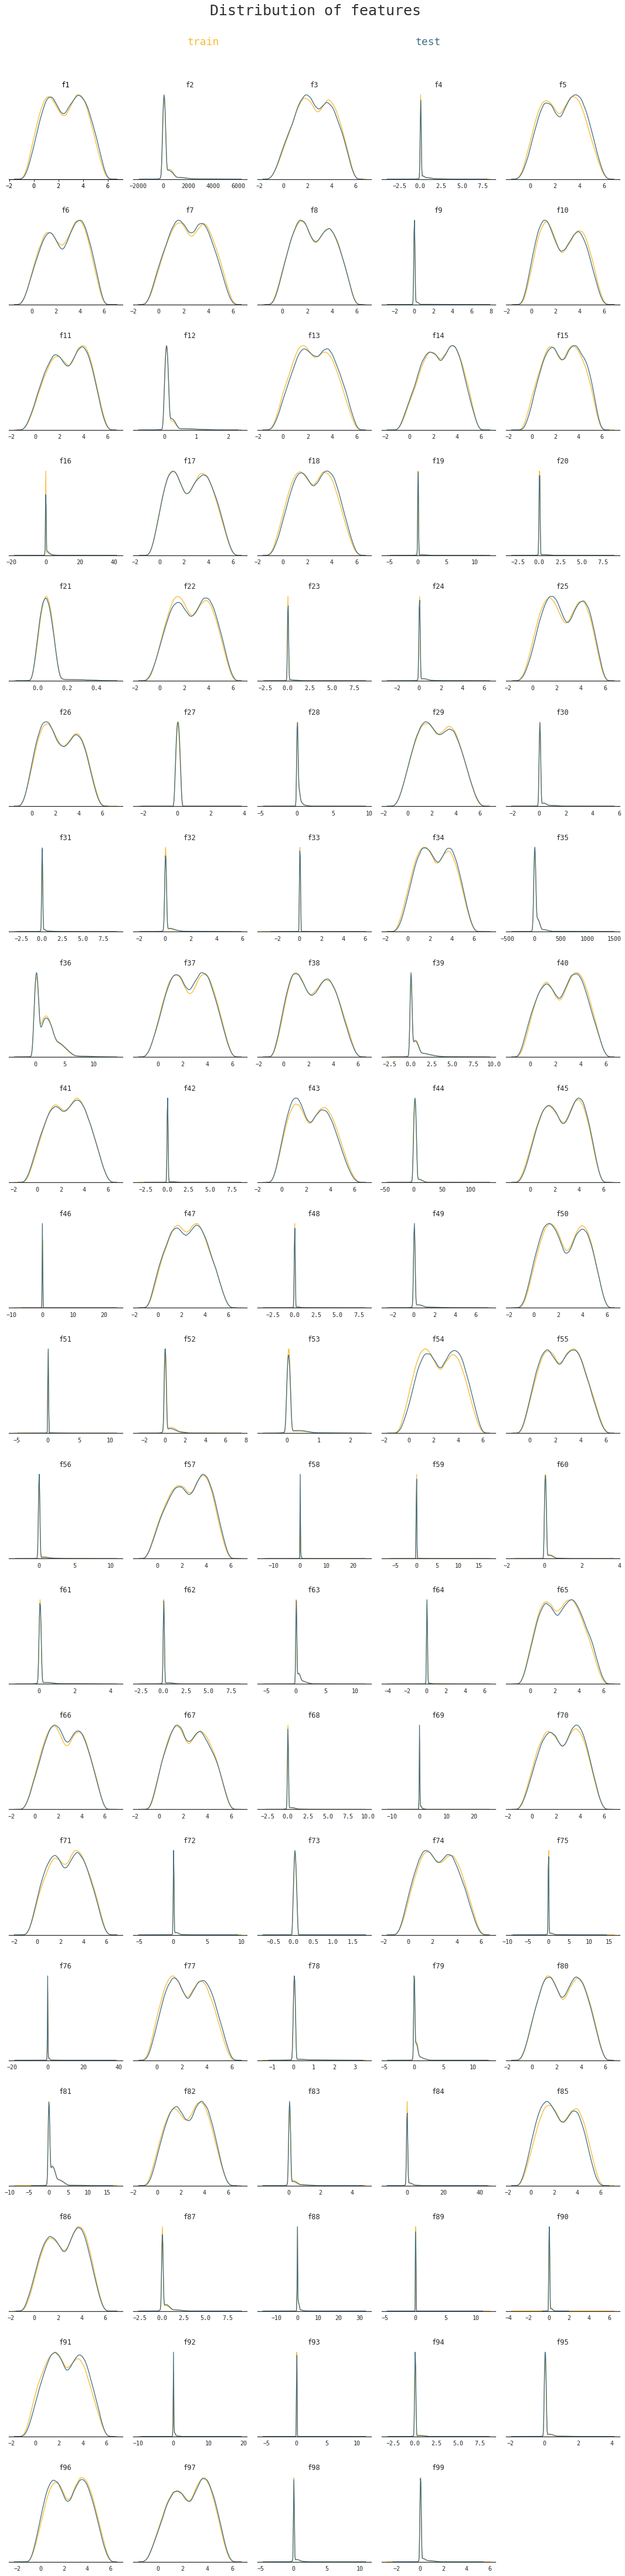

In [9]:
plot_feature_distribution(train.select_dtypes(include='float64') , test.select_dtypes(include='float64') )

# Target distribution

<AxesSubplot:ylabel='target'>

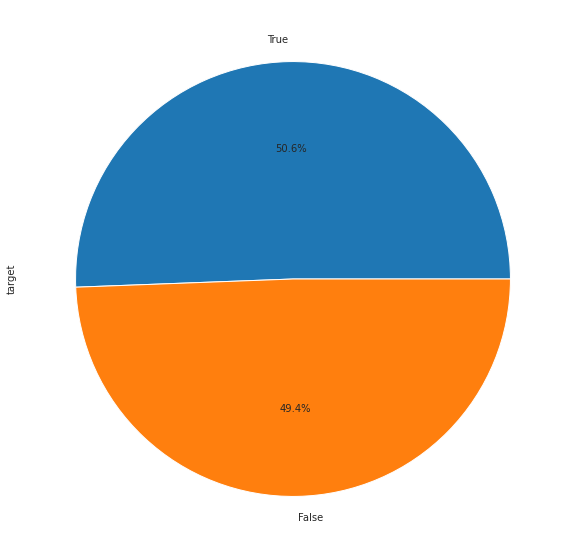

In [10]:
train.target.value_counts().plot(kind='pie', figsize=(10, 10), autopct='%1.1f%%')